<a href="https://colab.research.google.com/github/IrineuBovoJunior398/P-S_GRADUA-O_IA_UTFPR/blob/main/SQLite_CONEX%C3%83O_COLAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive


/tmp/ipykernel_2639/3083081242.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='produto', y='total_valor', palette='viridis')


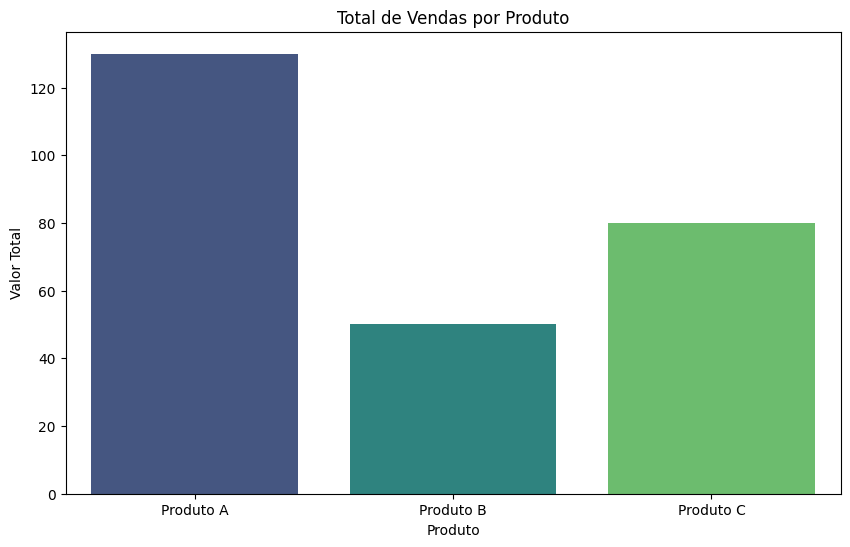

In [ ]:
# Script completo para Google Colab: Manipulação de SQLite com persistência no Google Drive e visualização com Seaborn

import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

# Mounting: Montar o Google Drive para acessar arquivos persistentes no Colab
# Isso permite que o script acesse arquivos no Drive, garantindo que dados sejam salvos permanentemente
# em vez de serem perdidos ao reiniciar a sessão do Colab.
drive.mount('/content/drive')

# Definir o caminho para o arquivo .db no Drive
# Persistence: O arquivo .db é armazenado no Google Drive, permitindo que os dados persistam
# entre sessões do Colab. Isso significa que as alterações no banco de dados são salvas fisicamente
# e podem ser recuperadas em execuções futuras.
db_path = '/content/drive/My Drive/vendas.db'

# Estabelecer conexão SQLite com o arquivo físico
conn = sqlite3.connect(db_path)

# Criar a tabela 'vendas_persistentes' se ela não existir
# Usando IF NOT EXISTS para evitar erros se a tabela já foi criada anteriormente.
create_table_query = '''
CREATE TABLE IF NOT EXISTS vendas_persistentes (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    produto TEXT NOT NULL,
    quantidade INTEGER NOT NULL,
    valor REAL NOT NULL
);
'''
conn.execute(create_table_query)

# Verificar se a tabela está vazia e inserir dados apenas se estiver vazia
# Isso evita duplicação de dados em execuções subsequentes.
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM vendas_persistentes")
if cursor.fetchone()[0] == 0:
    # Inserir dados de exemplo
    insert_data_query = '''
    INSERT INTO vendas_persistentes (produto, quantidade, valor)
    VALUES
        ('Produto A', 10, 100.0),
        ('Produto B', 5, 50.0),
        ('Produto C', 8, 80.0),
        ('Produto A', 3, 30.0);
    '''
    conn.execute(insert_data_query)
    # Commit: Salvar as alterações no banco de dados. O commit garante que as inserções sejam
    # persistidas no arquivo físico no Drive, tornando-as permanentes.
    conn.commit()

# Realizar uma consulta SQL para obter os dados
query = "SELECT produto, SUM(quantidade) as total_quantidade, SUM(valor) as total_valor FROM vendas_persistentes GROUP BY produto"
df = pd.read_sql_query(query, conn)

# Fechar a conexão
conn.close()

# Gerar um gráfico de barras com Seaborn
# Usando os dados da consulta para visualizar vendas por produto.
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='produto', y='total_valor', palette='viridis')
plt.title('Total de Vendas por Produto')
plt.xlabel('Produto')
plt.ylabel('Valor Total')
plt.show()